<a href="https://colab.research.google.com/github/NganTran-185/cpi-volatility-analysis/blob/main/Stock_Market_Reaction_to_Macroeconomic_Anouncement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STOCK MARKET REACTION TO MACROECONOMIC ANNOUNCEMENT PROJECT**


**INTRODUCTION:**
Macroeconomic announcements play a critical role in shaping financial market expectations. Among them, CPI inflation releases are closely monitored due to their implications for monetary policy.
This project examines whether CPI announcements are associated with increased short-term market volatility, using an event-driven machine learning framework.

**DATA DESCRIPTION: **
- S&P 500 daily price data from Yahoo Finance
- CPI inflation data from FRED (CPIAUCSL)
- Daily frequency from 2015-2025

**FEATURE ENGINEERING:**
Key engineered features include:
- Aligning CPI to actual release dates
- Daily log returns
- Rolling 20-day volatility
- CPI release indicator aligned with trading days
Volatility is chosen as the prediction target due to its stronger relationship with macroeconomic uncertainty.

##1. Data ingestion



In [19]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

START = '2015-01-01'
END   = '2025-01-01'

# S&P 500
sp500_raw = yf.download('^GSPC', start=START, end=END, progress=False, auto_adjust=True)
sp500_raw.columns = sp500_raw.columns.droplevel(1)


sp500 = sp500_raw.reset_index()
sp500 = sp500.rename(columns={'Date': 'date'})
sp500['date'] = pd.to_datetime(sp500['date'])
sp500 = sp500.set_index('date')

# log returns
sp500['return'] = np.log(sp500['Close'] / sp500['Close'].shift(1))
sp500 = sp500.dropna(subset=['return'])

print(f'S&P 500 loaded: {len(sp500)} trading days ({sp500.index.min().date()} to {sp500.index.max().date()})')
sp500[['Close', 'return']].head()


S&P 500 loaded: 2515 trading days (2015-01-05 to 2024-12-31)


Price,Close,return
date,,
2015-01-05,2020.579956,-0.018447
2015-01-06,2002.609985,-0.008933
2015-01-07,2025.900024,0.011563
2015-01-08,2062.139893,0.017730
2015-01-09,2044.810059,-0.008439


In [20]:
cpi_raw = web.DataReader('CPIAUCSL', 'fred', dt.datetime(2014, 1, 1), dt.datetime(2025, 1, 1))
cpi_raw.index = pd.to_datetime(cpi_raw.index)

# VIX from FRED (VIXCLS)
vix = web.DataReader('VIXCLS', 'fred', START, END)
vix.index = pd.to_datetime(vix.index)
vix.columns = ['VIX']

print('CPI rows:', len(cpi_raw))
cpi_raw.tail()

CPI rows: 133


,CPIAUCSL
DATE,
2024-09-01,314.732
2024-10-01,315.631
2024-11-01,316.528
2024-12-01,317.604
2025-01-01,318.961


##2. Align CPI to actual release date

In [21]:
trading_days = sp500.index

def next_trading_day(date, trading_days):
    future = trading_days[trading_days >= date]
    return future[0] if len(future) > 0 else None

# CPI is released roughly 12 calendar days after month-end
# (i.e., for January CPI, the release is around Feb 10–14)
# FRED timestamps it as the 1st of the REFERENCE month.
# We shift forward by ~12 days then snap to next trading day.
RELEASE_LAG_DAYS = 12  # approximate calendar day lag

release_dates = []
for idx_date in cpi_raw.index:
    approx_release = idx_date + pd.DateOffset(days=RELEASE_LAG_DAYS)
    td = next_trading_day(approx_release, trading_days)
    if td is not None:
        release_dates.append(td)

release_dates = pd.DatetimeIndex(release_dates).unique()

# Mark release days on the trading calendar
sp500['cpi_release'] = sp500.index.isin(release_dates).astype(int)

print(f'CPI release days marked: {sp500["cpi_release"].sum()} (expected ~{len(cpi_raw[cpi_raw.index >= START])} for this window)')
sp500[sp500['cpi_release'] == 1][['Close', 'return', 'cpi_release']].head(8)

CPI release days marked: 121 (expected ~121 for this window)


Price,Close,return,cpi_release
date,,,
2015-01-05,2020.579956,-0.018447,1
2015-01-13,2023.030029,-0.002582,1
2015-02-13,2096.989990,0.004066,1
2015-03-13,2053.399902,-0.006093,1
2015-04-13,2092.429932,-0.004592,1
2015-05-13,2098.479980,-0.000305,1
2015-06-15,2084.429932,-0.004633,1
2015-07-13,2099.600098,0.011005,1


##3. Feature Engineering

In [22]:
# CPI Surprise (actual vs. naïve lag forecast)
# Naïve forecast = previous month's YoY CPI change.
cpi_raw['cpi_yoy'] = cpi_raw['CPIAUCSL'].pct_change(12) * 100   # YoY %
cpi_raw['cpi_forecast'] = cpi_raw['cpi_yoy'].shift(1)           # lag 1 as naive forecast
cpi_raw['cpi_surprise'] = cpi_raw['cpi_yoy'] - cpi_raw['cpi_forecast']  # surprise = actual - expected

# Map each release date -> its surprise value
surprise_map = {}
for i, idx_date in enumerate(cpi_raw.index):
    approx_release = idx_date + pd.DateOffset(days=RELEASE_LAG_DAYS)
    td = next_trading_day(approx_release, trading_days)
    if td is not None and not pd.isna(cpi_raw['cpi_surprise'].iloc[i]):
        surprise_map[td] = cpi_raw['cpi_surprise'].iloc[i]

sp500['cpi_surprise'] = sp500.index.map(surprise_map).astype(float)
# Fill non-release days with 0 (no surprise)
sp500['cpi_surprise'] = sp500['cpi_surprise'].fillna(0)

# Rolling volatility (multiple windows)
sp500['vol_5d']  = sp500['return'].rolling(5).std()
sp500['vol_20d'] = sp500['return'].rolling(20).std()
sp500['vol_60d'] = sp500['return'].rolling(60).std()

# Lagged returns
sp500['return_lag1'] = sp500['return'].shift(1)
sp500['return_lag5'] = sp500['return'].shift(5)

# VIX merge (daily, already on trading days)
sp500 = sp500.join(vix, how='left')
sp500['VIX'] = sp500['VIX'].ffill()

# Event window flags (t-1, t, t+1)
sp500['cpi_t']   = sp500['cpi_release']
sp500['cpi_tm1'] = sp500['cpi_release'].shift(1).fillna(0)   # day before
sp500['cpi_tp1'] = sp500['cpi_release'].shift(-1).fillna(0)  # day after

# Target: will next-day volatility exceed its 60-day mean?
sp500['vol_spike'] = (
    sp500['vol_20d'].shift(-1) > sp500['vol_20d'].rolling(60).mean()
).astype(int)

# Drop rows with NaN from rolling windows
sp500 = sp500.dropna()

print(f'Final dataset: {len(sp500)} rows')
print(f'vol_spike balance: {sp500["vol_spike"].value_counts(normalize=True).to_dict()}')
sp500[['return', 'cpi_release', 'cpi_surprise', 'vol_5d', 'vol_20d', 'VIX', 'vol_spike']].head()

Final dataset: 2456 rows
vol_spike balance: {0: 0.5468241042345277, 1: 0.4531758957654723}


,return,cpi_release,cpi_surprise,vol_5d,vol_20d,VIX,vol_spike
date,,,,,,,
2015-03-31,-0.008835,0,0.0,0.010327,0.009312,15.29,0
2015-04-01,-0.003973,0,0.0,0.007952,0.009304,15.11,0
2015-04-02,0.003523,0,0.0,0.007973,0.009347,14.67,0
2015-04-06,0.006587,0,0.0,0.008361,0.008920,14.74,0
2015-04-07,-0.002064,0,0.0,0.006111,0.008890,14.78,0


##4. Event Windows

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Split into event / non-event windows
event_mask = (sp500['cpi_t'] == 1) | (sp500['cpi_tm1'] == 1) | (sp500['cpi_tp1'] == 1)
event_days     = sp500[event_mask]
non_event_days = sp500[~event_mask]

print('--- Return comparison ---')
print(f"Event window  | mean: {event_days['return'].mean():.5f} | std: {event_days['return'].std():.5f}")
print(f"Non-event     | mean: {non_event_days['return'].mean():.5f} | std: {non_event_days['return'].std():.5f}")

from scipy.stats import ttest_ind, levene
t_stat, p_val = ttest_ind(event_days['return'], non_event_days['return'], equal_var=False)
lev_stat, lev_p = levene(event_days['return'], non_event_days['return'])
print(f"\nWelch t-test  | t={t_stat:.4f}, p={p_val:.4f}")
print(f"Levene (variance) | stat={lev_stat:.4f}, p={lev_p:.4f}")

--- Return comparison ---
Event window  | mean: 0.00078 | std: 0.01357
Non-event     | mean: 0.00036 | std: 0.01090

Welch t-test  | t=0.5529, p=0.5806
Levene (variance) | stat=0.1839, p=0.6681


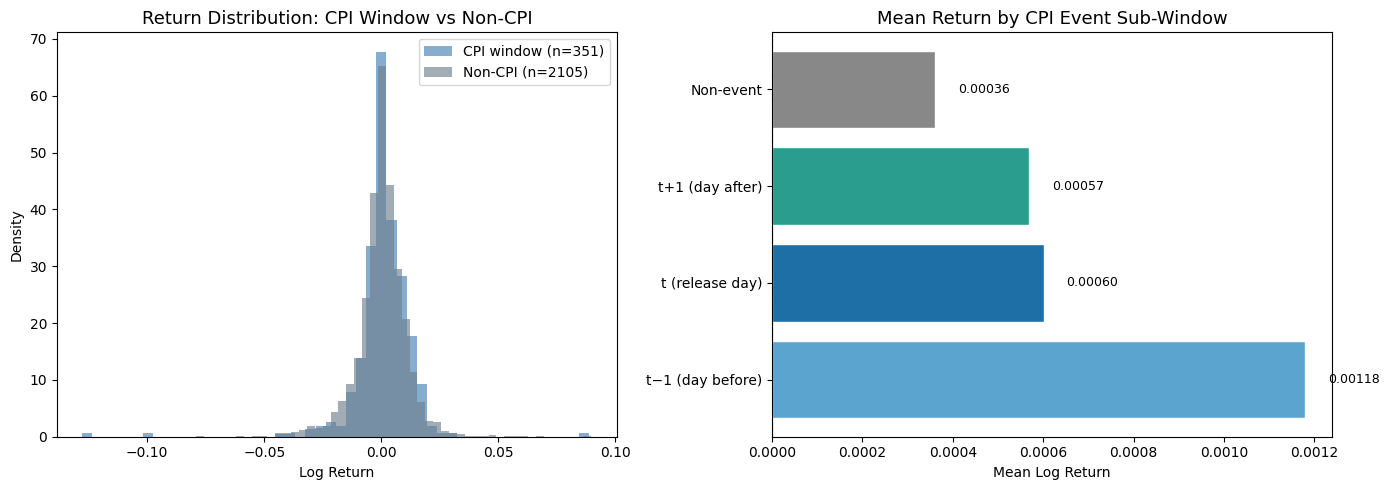

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return distributions
axes[0].hist(event_days['return'], bins=50, alpha=0.65, density=True,
             color='steelblue', label=f'CPI window (n={len(event_days)})')
axes[0].hist(non_event_days['return'], bins=50, alpha=0.65, density=True,
             color='slategray', label=f'Non-CPI (n={len(non_event_days)})')
axes[0].set_title('Return Distribution: CPI Window vs Non-CPI', fontsize=13)
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Mean return by sub-window
labels = ['t−1 (day before)', 't (release day)', 't+1 (day after)', 'Non-event']
means  = [
    sp500[sp500['cpi_tm1'] == 1]['return'].mean(),
    sp500[sp500['cpi_t']   == 1]['return'].mean(),
    sp500[sp500['cpi_tp1'] == 1]['return'].mean(),
    non_event_days['return'].mean()
]
colors = ['#5ba4cf', '#1d6fa5', '#2a9d8f', '#888888']
axes[1].barh(labels, means, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean Return by CPI Event Sub-Window', fontsize=13)
axes[1].set_xlabel('Mean Log Return')
for i, v in enumerate(means):
    axes[1].text(v + 0.00005, i, f'{v:.5f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Event Study — Cumulative Abnormal Returns (CAR)

Standard academic event study: compute the average cumulative return
in a [−5, +5] trading day window around each CPI release,
subtracting the unconditional mean return as the "normal" benchmark.

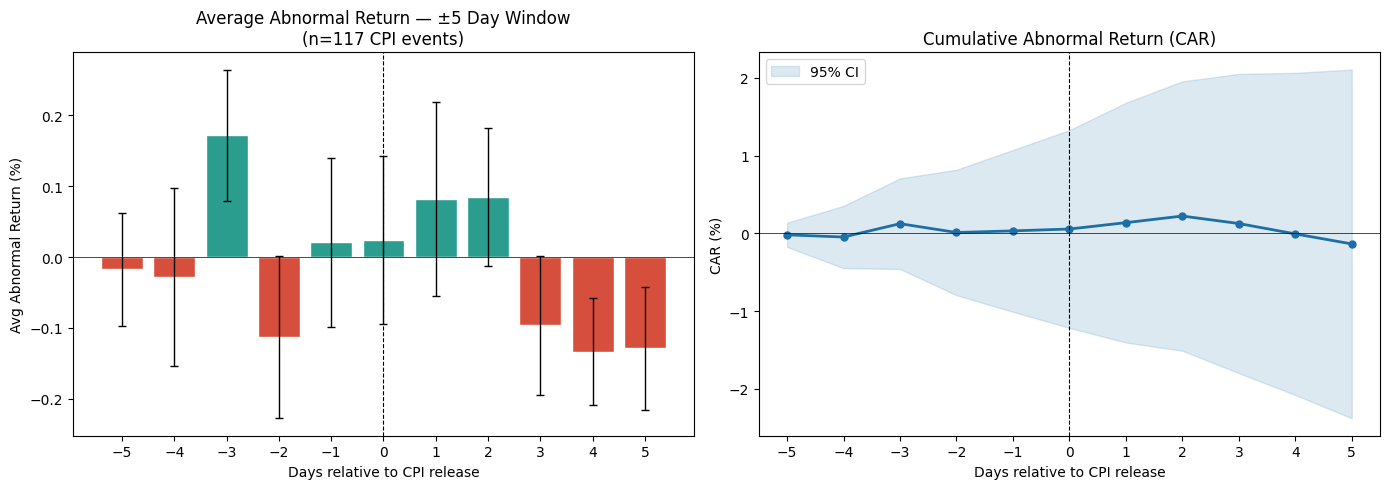

Events analyzed: 117
CAR at day 0 (release): 0.0574%
CAR at day +5:          -0.1345%


In [25]:
WINDOW = 5   # days before and after release

normal_return = non_event_days['return'].mean()  # unconditional baseline

release_day_indices = sp500.index[sp500['cpi_t'] == 1]
sp500_list = list(sp500.index)

car_matrix = []

for rel_date in release_day_indices:
    pos = sp500_list.index(rel_date)
    start_pos = pos - WINDOW
    end_pos   = pos + WINDOW + 1
    if start_pos < 0 or end_pos > len(sp500_list):
        continue
    window_dates = sp500_list[start_pos:end_pos]
    window_returns = sp500.loc[window_dates, 'return'].values
    # Abnormal return = actual - normal
    abnormal = window_returns - normal_return
    car_matrix.append(abnormal)

car_matrix = np.array(car_matrix)  # shape: (n_events, 2*WINDOW+1)
days_rel = np.arange(-WINDOW, WINDOW + 1)

mean_ar  = car_matrix.mean(axis=0)
se_ar    = car_matrix.std(axis=0) / np.sqrt(len(car_matrix))
mean_car = np.cumsum(mean_ar)      # cumulative

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Abnormal Return per day
axes[0].bar(days_rel, mean_ar * 100,
            color=['#d64f3c' if v < 0 else '#2a9d8f' for v in mean_ar],
            edgecolor='white')
axes[0].errorbar(days_rel, mean_ar * 100, yerr=se_ar * 100,
                 fmt='none', color='black', capsize=3, linewidth=1)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title(f'Average Abnormal Return — ±{WINDOW} Day Window\n(n={len(car_matrix)} CPI events)', fontsize=12)
axes[0].set_xlabel('Days relative to CPI release')
axes[0].set_ylabel('Avg Abnormal Return (%)')
axes[0].set_xticks(days_rel)

# Cumulative Abnormal Return
axes[1].plot(days_rel, mean_car * 100, color='#1d6fa5', linewidth=2, marker='o', markersize=5)
axes[1].fill_between(days_rel,
                     (mean_car - 1.96 * se_ar.cumsum()) * 100,
                     (mean_car + 1.96 * se_ar.cumsum()) * 100,
                     alpha=0.15, color='#1d6fa5', label='95% CI')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Cumulative Abnormal Return (CAR)', fontsize=12)
axes[1].set_xlabel('Days relative to CPI release')
axes[1].set_ylabel('CAR (%)')
axes[1].set_xticks(days_rel)
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Events analyzed: {len(car_matrix)}')
print(f'CAR at day 0 (release): {mean_car[WINDOW]*100:.4f}%')
print(f'CAR at day +5:          {mean_car[-1]*100:.4f}%')

## 6. Regime Analysis — Low vs. High Inflation

CPI release day stats by inflation regime:
regime       High Inflation  Low Inflation
n_events          38.000000      79.000000
mean_return       -0.000306       0.001038
std_return         0.013372       0.012603
mean_vol           0.009909       0.009233
mean_vix          20.003158      17.608481


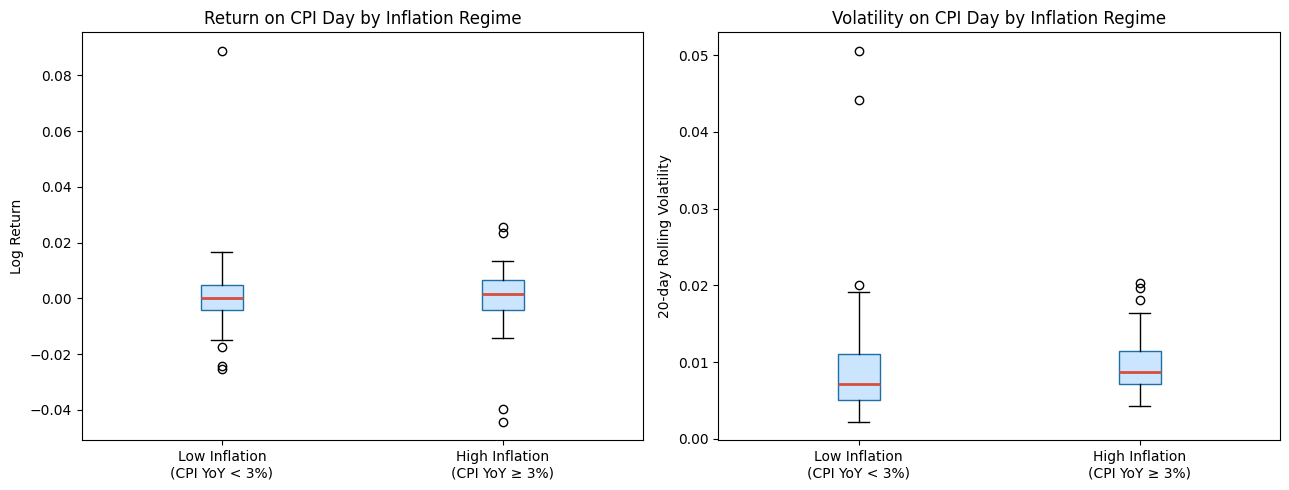

In [26]:
# Define regimes based on YoY CPI level
# Low inflation: CPI YoY < 3% (2015-2020)
# High inflation: CPI YoY >= 3% (2021-2023)

# Build a daily CPI YoY series aligned to trading days
cpi_yoy_daily = cpi_raw[['cpi_yoy']].copy()
cpi_yoy_daily = cpi_yoy_daily.reindex(sp500.index, method='ffill')
sp500['cpi_yoy'] = cpi_yoy_daily['cpi_yoy']

INFLATION_THRESHOLD = 3.0  # percent YoY
sp500['regime'] = np.where(sp500['cpi_yoy'] >= INFLATION_THRESHOLD, 'High Inflation', 'Low Inflation')

regime_stats = sp500[sp500['cpi_t'] == 1].groupby('regime').agg(
    n_events       = ('return', 'count'),
    mean_return    = ('return', 'mean'),
    std_return     = ('return', 'std'),
    mean_vol       = ('vol_20d', 'mean'),
    mean_vix       = ('VIX', 'mean'),
).round(6)

print('CPI release day stats by inflation regime:')
print(regime_stats.T)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title, ylabel in zip(
    axes,
    ['return', 'vol_20d'],
    ['Return on CPI Day by Inflation Regime', 'Volatility on CPI Day by Inflation Regime'],
    ['Log Return', '20-day Rolling Volatility']
):
    data_by_regime = [sp500[(sp500['cpi_t'] == 1) & (sp500['regime'] == r)][col]
                      for r in ['Low Inflation', 'High Inflation']]
    ax.boxplot(data_by_regime, labels=['Low Inflation\n(CPI YoY < 3%)', 'High Inflation\n(CPI YoY ≥ 3%)'],
               patch_artist=True,
               boxprops=dict(facecolor='#cce5ff', color='#1d6fa5'),
               medianprops=dict(color='#d64f3c', linewidth=2))
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

## 7. ML Model — Walk-Forward Cross-Validation

 `TimeSeriesSplit`
to correctly respect temporal ordering and avoid look-ahead bias.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# Feature set (no future data; all known at end of trading day t)
FEATURES = [
    'cpi_release',    # binary: is today a CPI release day?
    'cpi_surprise',   # CPI surprise (actual - naive forecast), 0 on non-release days
    'vol_5d',         # short-term rolling vol
    'vol_20d',        # medium-term rolling vol (original)
    'vol_60d',        # long-term rolling vol
    'return_lag1',    # yesterday's return
    'return_lag5',    # 5-day lagged return
    'VIX',            # market fear gauge
]

X = sp500[FEATURES].copy()
y = sp500['vol_spike'].copy()

print(f'Features: {FEATURES}')
print(f'Samples:  {len(X)}')
print(f'Target balance: {y.value_counts(normalize=True).to_dict()}')

Features: ['cpi_release', 'cpi_surprise', 'vol_5d', 'vol_20d', 'vol_60d', 'return_lag1', 'return_lag5', 'VIX']
Samples:  2456
Target balance: {0: 0.5468241042345277, 1: 0.4531758957654723}


In [28]:
# Walk-forward cross-validation
tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Logistic Regression (baseline)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=6,
                                       class_weight='balanced', random_state=42))
    ]),
}

results = {}
for name, pipe in models.items():
    auc_scores = cross_val_score(pipe, X, y, cv=tscv, scoring='roc_auc')
    acc_scores = cross_val_score(pipe, X, y, cv=tscv, scoring='accuracy')
    results[name] = {
        'AUC mean': auc_scores.mean(),
        'AUC std':  auc_scores.std(),
        'Acc mean': acc_scores.mean(),
        'Acc std':  acc_scores.std(),
    }
    print(f"{name}")
    print(f"  ROC-AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print(f"  Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print()

Logistic Regression (baseline)
  ROC-AUC: 0.9662 ± 0.0213
  Accuracy: 0.8636 ± 0.0979

Random Forest
  ROC-AUC: 0.8426 ± 0.0645
  Accuracy: 0.7218 ± 0.0805



=== Random Forest — Holdout Test Set ===
Accuracy : 0.7134
ROC-AUC  : 0.8371

              precision    recall  f1-score   support

           0       0.77      0.74      0.76       297
           1       0.63      0.67      0.65       195

    accuracy                           0.71       492
   macro avg       0.70      0.71      0.70       492
weighted avg       0.72      0.71      0.71       492



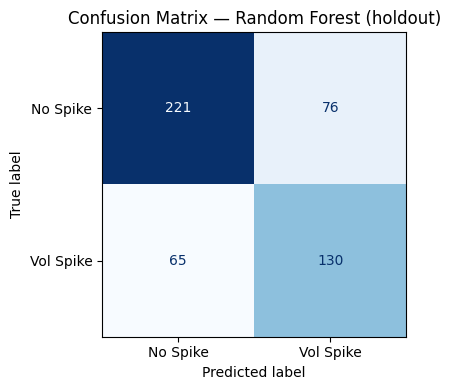

In [29]:
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

best_pipe = models['Random Forest']
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print('=== Random Forest — Holdout Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
                                         display_labels=['No Spike', 'Vol Spike'],
                                         colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest (holdout)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. SHAP Feature Importance

<Figure size 900x500 with 0 Axes>

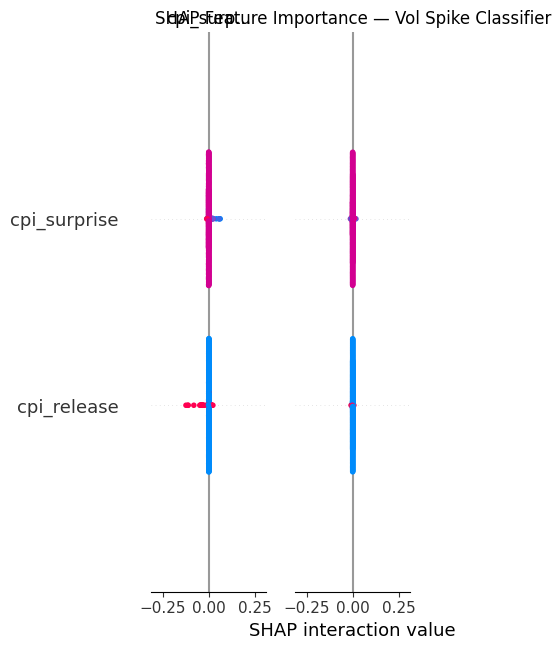

<Figure size 1000x600 with 0 Axes>

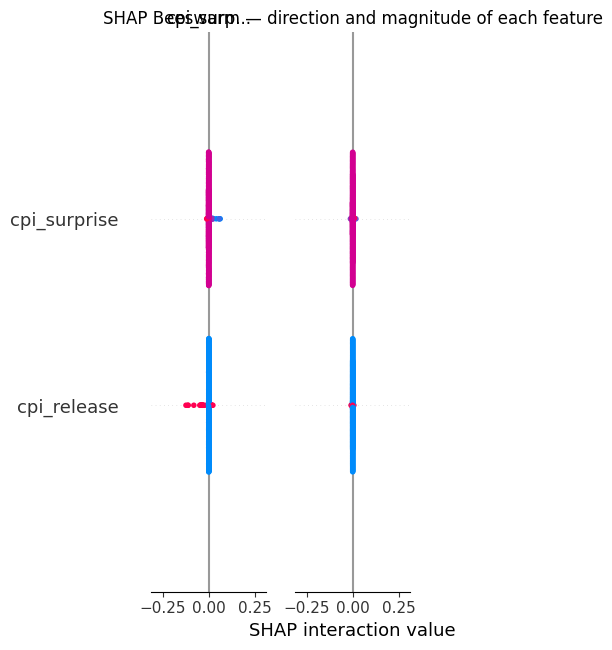

In [30]:
try:
    import shap

    rf_model = best_pipe.named_steps['clf']
    X_test_scaled = best_pipe.named_steps['scaler'].transform(X_test)

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_scaled)

    # shap_values is a list [class0, class1] for classifiers
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(9, 5))
    shap.summary_plot(sv, X_test_scaled, feature_names=FEATURES,
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — Vol Spike Classifier', fontsize=12)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_test_scaled, feature_names=FEATURES, show=False)
    plt.title('SHAP Beeswarm — direction and magnitude of each feature', fontsize=12)
    plt.tight_layout()
    plt.show()

except ImportError:
    print('shap not installed. Run: pip install shap')

    # Fallback: built-in RF feature importances
    rf_model = best_pipe.named_steps['clf']
    importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Random Forest Feature Importances (Gini)', fontsize=12)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 9. GARCH(1,1) Volatility Model

Rolling standard deviation (used in the original notebook) is a naïve proxy.
`GARCH(1,1)` is the standard econometric model for financial return volatility —
it captures volatility clustering (large moves follow large moves).
Here we fit GARCH and plot conditional volatility against CPI release days.

arch library not installed. Run: pip install arch
Showing rolling volatility comparison instead.


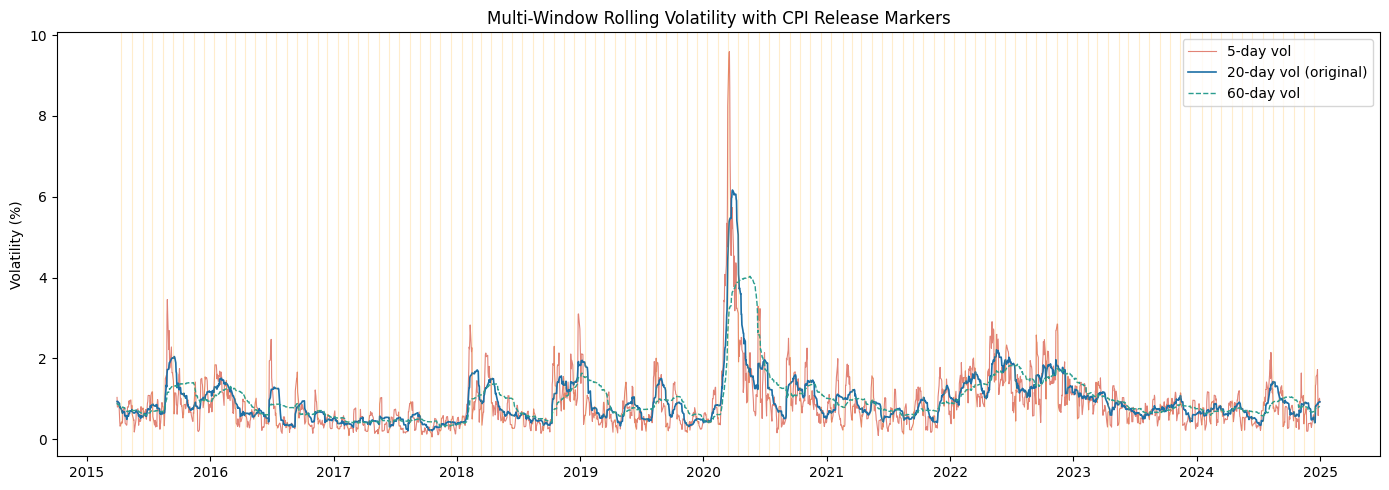

In [31]:
try:
    from arch import arch_model

    returns_pct = sp500['return'] * 100  # GARCH works better in percent

    garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='normal')
    garch_result = garch_model.fit(disp='off')

    print(garch_result.summary())

    cond_vol = garch_result.conditional_volatility  # annualized if multiplied by sqrt(252)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # S&P 500 returns
    axes[0].plot(sp500.index, sp500['return'] * 100, color='#888888',
                 linewidth=0.6, alpha=0.8, label='Daily return (%)')
    axes[0].set_ylabel('Return (%)')
    axes[0].set_title('S&P 500 Daily Returns', fontsize=12)
    for d in sp500.index[sp500['cpi_t'] == 1]:
        axes[0].axvline(d, color='#d64f3c', alpha=0.25, linewidth=0.8)

    # GARCH conditional volatility
    axes[1].plot(cond_vol.index, cond_vol.values, color='#1d6fa5',
                 linewidth=1.2, label='GARCH(1,1) conditional vol')
    axes[1].plot(sp500.index, sp500['vol_20d'] * 100, color='#2a9d8f',
                 linewidth=1, linestyle='--', alpha=0.7, label='20-day rolling std (original)')
    for d in sp500.index[sp500['cpi_t'] == 1]:
        axes[1].axvline(d, color='#d64f3c', alpha=0.25, linewidth=0.8,
                        label='CPI release' if d == sp500.index[sp500['cpi_t'] == 1][0] else None)
    axes[1].set_ylabel('Volatility (%)')
    axes[1].set_title('GARCH(1,1) vs Rolling Std — with CPI Release Markers', fontsize=12)
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

except ImportError:
    print('arch library not installed. Run: pip install arch')
    print('Showing rolling volatility comparison instead.')

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(sp500.index, sp500['vol_5d'] * 100, color='#d64f3c',
            linewidth=0.8, alpha=0.7, label='5-day vol')
    ax.plot(sp500.index, sp500['vol_20d'] * 100, color='#1d6fa5',
            linewidth=1.2, label='20-day vol (original)')
    ax.plot(sp500.index, sp500['vol_60d'] * 100, color='#2a9d8f',
            linewidth=1, linestyle='--', label='60-day vol')
    for d in sp500.index[sp500['cpi_t'] == 1]:
        ax.axvline(d, color='orange', alpha=0.2, linewidth=0.8)
    ax.set_title('Multi-Window Rolling Volatility with CPI Release Markers', fontsize=12)
    ax.set_ylabel('Volatility (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()